In [1]:
from ase import atoms
from rdkit.Chem import AllChem
import numpy as np
from ase.calculators.lj import LennardJones
from ase.optimize import BFGS
from ase.visualize import view
from ase import units
from rdkit.Chem import rdMolAlign
from rdkit import Chem
import matplotlib.pyplot as plt
from tblite.ase import TBLite
from rdkit.Chem import Descriptors
import math

: 

Molecule setup

In [12]:
input = "Cn1cnc2n(C)c(=O)n(C)c(=O)c12"

mol = AllChem.MolFromSmiles(input)
mol = AllChem.AddHs(mol)

2. conformer generation
3. Geometry optimization
4. save optimized structures
- initialize report

In [13]:
n_rotatable = Descriptors.NumRotatableBonds(mol)
NUM_CONFS = min(25 + 15 * n_rotatable, 300) # 300 max conformers, but scales based on molecule complexity

F_MAX = 0.05
ENERGY_THRESHOLD = 10.0 # kcal/mol    change to filtering conformers based on threshold determined by boltzman distribution, ex. remove conformer if population < threshold

RMSD_THRESHOLD = 0.75 # in angstroms, upper threshold for how similar two conformers must be to be considered duplicates
# can be ambiguous/tuned based on molecule size/complexity...maybe implement same algorithm as NUM_CONFS to determine this value based on size + complexity?



params = AllChem.ETKDGv3()
params.randomSeed = 42

AllChem.EmbedMultipleConfs(
    mol,
    numConfs=NUM_CONFS,
    params=params
)


# find proper optimization value




results = []

for conf in mol.GetConformers():
    conf_id = conf.GetId()

    # construct ASE atoms object from conformer
    positions = conf.GetPositions()
    symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    atom = atoms.Atoms(symbols=symbols, positions=positions)

    atom.calc = TBLite(method="GFN2-xTB")
    opt = BFGS(atom)
    opt.run(fmax=F_MAX)

# update rdkit conformer positions with optimized positions from ASE
    optimized_positions = atom.get_positions()
    for idx in range(mol.GetNumAtoms()):
        x, y, z = optimized_positions[idx]
        conf.SetAtomPosition(idx, (float(x), float(y), float(z)))


    # create list of "results" dict, contains each conformer profile
    results.append({
        "id": conf_id,
        "energy": atom.get_potential_energy() * 23.0605, # stores energy in eV --> convert to kcal/mol
        "conformer": conf, # rdkit conformer object
        "atoms": atom.copy() # ASE atoms object for each conformer
    })

results.sort(key=lambda x: x["energy"])
print(f"Number of prefiltered conformers: {len(results)}")

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -41.71330919529  -4.2210624E+01   1.8883831E-01
      2     -42.09737902996  -3.8406983E-01   7.5493314E-02
      3     -42.12088208063  -2.3503051E-02   4.4601783E-02
      4     -42.12365857359  -2.7764930E-03   1.3700145E-02
      5     -42.12540990398  -1.7513304E-03   6.6994300E-03
      6     -42.12606871433  -6.5881036E-04   2.4422599E-03
      7     -42.12608156899  -1.2854654E-05   1.3299562E-03
      8     -42.12610874013  -2.7171142E-05   3.9885910E-04
      9     -42.12610965969  -9.1955717E-07   2.0638508E-04
     10     -42.12610997978  -3.2009336E-07   6.9933154E-05
     11     -42.12611003450  -5.4720296E-08   3.0286182E-05
     12     -42.12611003860  -4.1017429E-09   7.7238449E-06
------------------------------------------------------------

 total:                             

5. Energy filtering + Boltzman distribution
- remove all optimized conformers 5 kcal/mol above minimum value, not likely to be physically formed


Boltzman distribution (how commonly each conformer is occupied physically)

$$P_i = \frac{e^{-\Delta E_i / (RT)}}{\sum_{j} e^{-\Delta E_j / (RT)}}$$

- use relative energies between conformers, not absolute ones like outputed from xTB

In [16]:
min_energy = results[0]["energy"]

# Boltzman population analysis on unfiltered conformers. filtering is after
TEMPERATURE = 298.15 # in kelvin, can be adjusted based on needs, but this plays a role in boltzman distribution calculations
R = 0.0019872041  # in kcal/(mol*K)
for result in results:
    result['relative_energy'] = result['energy'] - min_energy

    delta_e = result['relative_energy']
    boltz_factor = math.exp(-delta_e / (R * TEMPERATURE))

    result['boltzmann_factor'] = boltz_factor

partition_function = sum(result["boltzmann_factor"] for result in results)

for result in results:
    result['population'] = result['boltzmann_factor'] / partition_function


for result in results:
    print(
        f"Conf {result['id']:>2} | "
        f"E = {result['energy']:.2f} kcal/mol | "
        f"dE = {result['relative_energy']:.2f} | "
        f"Pop = {result['population']*100:.2f}%"
    )




# filtering part below
"""
conformer_list_filtered = []

for result in results:
    if result["energy"] - min_energy <= ENERGY_THRESHOLD:
        conformer_list_filtered.append(result)

conformer_list_filtered.sort(key=lambda x: x["energy"])

print(f"Number of filtered conformers: {len(conformer_list_filtered)}")
conformer_list_filtered
"""

Conf 14 | E = -26452.17 kcal/mol | dE = 0.00 | Pop = 5.97%
Conf 12 | E = -26452.12 kcal/mol | dE = 0.05 | Pop = 5.51%
Conf 11 | E = -26452.12 kcal/mol | dE = 0.05 | Pop = 5.49%
Conf  4 | E = -26452.11 kcal/mol | dE = 0.06 | Pop = 5.37%
Conf  0 | E = -26452.07 kcal/mol | dE = 0.10 | Pop = 5.05%
Conf 15 | E = -26452.01 kcal/mol | dE = 0.16 | Pop = 4.53%
Conf 20 | E = -26452.00 kcal/mol | dE = 0.17 | Pop = 4.48%
Conf 23 | E = -26452.00 kcal/mol | dE = 0.17 | Pop = 4.48%
Conf  7 | E = -26451.97 kcal/mol | dE = 0.20 | Pop = 4.23%
Conf 18 | E = -26451.97 kcal/mol | dE = 0.20 | Pop = 4.23%
Conf  5 | E = -26451.96 kcal/mol | dE = 0.21 | Pop = 4.17%
Conf 16 | E = -26451.93 kcal/mol | dE = 0.24 | Pop = 4.00%
Conf  3 | E = -26451.91 kcal/mol | dE = 0.26 | Pop = 3.86%
Conf 17 | E = -26451.89 kcal/mol | dE = 0.28 | Pop = 3.72%
Conf  6 | E = -26451.89 kcal/mol | dE = 0.28 | Pop = 3.71%
Conf 21 | E = -26451.87 kcal/mol | dE = 0.30 | Pop = 3.61%
Conf 13 | E = -26451.86 kcal/mol | dE = 0.31 | Pop = 3.5

'\nconformer_list_filtered = []\n\nfor result in results:\n    if result["energy"] - min_energy <= ENERGY_THRESHOLD:\n        conformer_list_filtered.append(result)\n\nconformer_list_filtered.sort(key=lambda x: x["energy"])\n\nprint(f"Number of filtered conformers: {len(conformer_list_filtered)}")\nconformer_list_filtered\n'

6. RMSD analysis
- pairwise comparisons of each conformer to determine similarity

In [5]:
# create dictionary with index of conformer: conformer id
index_map = {}
for idx, item in enumerate(conformer_list_filtered):
    index_map[idx] = item["id"]



# rdMolAlign.GetBestRMS() only takes molecule objects and considers conformers by their IDs

# create 0s matrix to store rmsd values
n_conf = len(conformer_list_filtered)

rmsd_matrix = np.zeros((n_conf, n_conf))



# fill in rms values by comparing each conformer to each other conformer (only upper triangle since symmetric)
for i in range(n_conf):
    for j in range(i + 1, n_conf):

        # pulls modified conformers from original mol object using conformer IDs
        id1 = conformer_list_filtered[i]["id"]
        id2 = conformer_list_filtered[j]["id"]

        rmsd_matrix[i, j] = rdMolAlign.GetBestRMS(
            mol, 
            mol, 
            prbId=id1, 
            refId=id2
        )
        rmsd_matrix[j, i] = rmsd_matrix[i, j]



# earlier conformer generation is not deterministic, so there can be different outcomes for filtered conformers
# implement random seed for debugging if needed
print(rmsd_matrix, "\n\n", "Index map: ",index_map)

[[0.         0.07892353 0.21280546 0.197153   0.20723767 0.17393637
  0.367489   0.25293109 0.47350728 0.3100493  0.40660261 0.21952016
  0.34037233 0.37113977 0.41084791 0.33592007 0.32416512 0.27495844
  0.4646977  0.36524882 0.3390382  0.46080662 0.43156434 0.43561109
  0.34537608]
 [0.07892353 0.         0.17169254 0.15444508 0.18822065 0.24659472
  0.37045532 0.29293409 0.43646095 0.36288461 0.434795   0.15901967
  0.34712475 0.39679773 0.41827509 0.35517502 0.26411901 0.20201302
  0.48615929 0.34154487 0.27104628 0.4103909  0.44832935 0.37712515
  0.40504675]
 [0.21280546 0.17169254 0.         0.03725345 0.18369923 0.32898828
  0.2430551  0.40746717 0.27890845 0.42216781 0.40610738 0.19968631
  0.30403488 0.41922475 0.3098568  0.44363541 0.25554156 0.22821377
  0.44250283 0.39046926 0.29049424 0.31721495 0.49813442 0.31101544
  0.45204196]
 [0.197153   0.15444508 0.03725345 0.         0.15405139 0.31779282
  0.26029822 0.38818942 0.29357523 0.40251512 0.41297113 0.20230064
  0.29

7. Heatmap visualization of rmsd_matrix

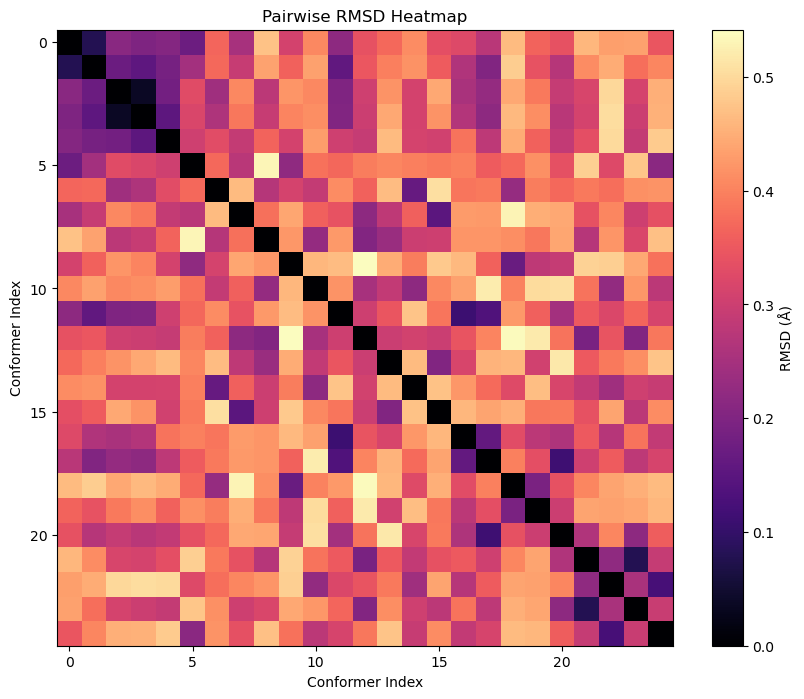

In [6]:
plt.figure(figsize=(10, 8))
plt.imshow(rmsd_matrix, cmap='magma', vmin=0, vmax=np.max(rmsd_matrix))
plt.colorbar(label="RMSD (Å)")

plt.xlabel("Conformer Index")
plt.ylabel("Conformer Index")

plt.title("Pairwise RMSD Heatmap")

plt.show()

8. Identify unique conformers (based on determined rmsd threshold)

In [8]:
unique_conformers = []

for conf in conformer_list_filtered:
    is_duplicate = False
    for unique_conf in unique_conformers:
        id1 = conf["id"]
        id2 = unique_conf["id"]

        rmsd = rdMolAlign.GetBestRMS(
            mol, 
            mol, 
            prbId=id1, 
            refId=id2
        )

        if rmsd < RMSD_THRESHOLD:
            is_duplicate = True
            break
    if not is_duplicate:
        unique_conformers.append(conf)
print(f"Number of unique conformers: {len(unique_conformers)}")

print("\n\n", "Unique conformers (ID, Energy in kcal/mol):")
for conf in unique_conformers:
    print(conf["id"], conf["energy"])

Number of unique conformers: 1


 Unique conformers (ID, Energy in kcal/mol):
14 -26452.169370625885


In [ ]:

'''
# generate ase Atoms object for more optimal conformer and view
genpositions = results[0]['conformer'].GetPositions()
gensymbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
genatom = atoms.Atoms(symbols=gensymbols, positions=genpositions)
view(genatom)
'''